## Case - Student Score

### Objectives

This analysis aims to:
1. Calculate the **average score** of all students in the dataset.
2. Analyze the **relationship between extracurricular participation and student scores** using Simple Linear Regression.

### 1. Load Data

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load dataset
student = pd.read_csv('student_performance.csv', index_col=0)
student.head()

,age,gender,study_hours,attendance,extracurricular,parental_education,region,score
Unnamed: 0,,,,,,,,
1745,15,male,0.9,82,yes,high school,east,9.56
1811,17,male,3.0,68,no,high school,north,12.27
2962,16,male,0.4,95,yes,high school,north,5.48
1118,18,female,2.4,53,yes,none,south,0.00
3773,18,male,1.0,97,no,high school,south,3.65


### 2. Exploratory Data Analysis (EDA)

Before we do analysis, we need to check the condition of the data: number of rows/columns, data type, and whether there are missing values.

In [3]:
# type data check
student.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4234 entries, 1745 to 569
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 4234 non-null   int64  
 1   gender              4234 non-null   object 
 2   study_hours         4234 non-null   float64
 3   attendance          4234 non-null   int64  
 4   extracurricular     4234 non-null   object 
 5   parental_education  4234 non-null   object 
 6   region              4234 non-null   object 
 7   score               4234 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 297.7+ KB


In [4]:
# Check missing values
student.isnull().sum()

age                   0
gender                0
study_hours           0
attendance            0
extracurricular       0
parental_education    0
region                0
score                 0
dtype: int64

There are no missing values ​​in the dataset. The data consists of 4,234 rows and 8 columns, with the target variable `score` being numeric.

In [5]:
# variabel extracurricular distribution
student['extracurricular'].value_counts()

extracurricular
no     2287
yes    1947
Name: count, dtype: int64

There are the 4,234 students, **2,287 students** did not participate in extracurricular activities (`no`) and **1,947 students** participated in extracurricular activities (`yes`).

#### Visualization Data

Because the `extracurricular` variable is categorical (`yes`/`no`), the following scatter plot displays the distribution of scores based on the two groups.

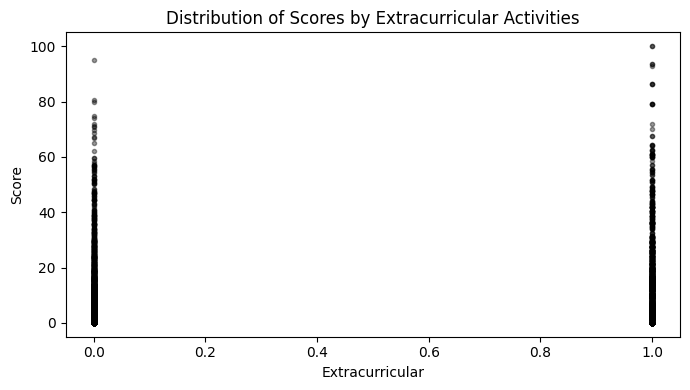

In [16]:
x = student['extracurricular']
y = student['score']

plt.figure(figsize=(7, 4))
plt.scatter(x, y, marker='.', color='k', alpha=0.4)
plt.xlabel('Extracurricular')
plt.ylabel('Score')
plt.title('Distribution of Scores by Extracurricular Activities')
plt.tight_layout()
plt.show()

### 3. Average Students Score

One of the objectives of the analysis is to calculate the average score of all students.

In [7]:
mean_score = np.mean(student['score'])
print(f'Average Student score: {mean_score:.4f}')

Average Student score: 11.3170


**The average score for all students is ≈ 11.31.** This value is also the intercept estimate for a null regression model, since $\hat{a} = \bar{y}$ hen there are no predictors.

The standard error of the mean is calculated as:

$$\text{std.err} = \frac{s}{\sqrt{n}}$$

In [8]:
std_err_mean = np.std(student['score'], ddof=1) / np.sqrt(len(student['score']))
print(f'standard error of the mean score: {std_err_mean:.4f}')

standard error of the mean score: 0.2078


> **Note:** Use `ddof=1` in `np.std()` to calculate *sample standard deviation* (divisor $n-1$), not *population standard deviation* (divisor $n$). This is important for consistency with the standard error output from statsmodels' OLS model.

### 4. Encoding Categorical Variabel

Linear regression requires numeric input. The `extracurricular` variable needs to be converted from `yes`/`no` to `1`/`0` using `LabelEncoder`.

In [9]:
# Use LabelEncoder to convert the smoker variable into numeric
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder Object and transform the smoker variable
student['extracurricular'] = LabelEncoder().fit_transform(student['extracurricular'])

# Display the 5th first row after transforming
student[["extracurricular","score"]].head()

,extracurricular,score
Unnamed: 0,,
1745,1,9.56
1811,0,12.27
2962,1,5.48
1118,1,0.00
3773,0,3.65


`LabelEncoder` automatically encodes in alphabetical order: `no` → **0**, `yes` → **1**. Ensure this mapping matches your desired interpretation before proceeding.

### 5. Build a Linear Regression Model

We use the `ols` function from `statsmodels` to estimate the model coefficients:

$$y = \hat{a} + \hat{b} \cdot x$$

where $y$ = score and $x$ = extracurricular (0 or 1).

In [10]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from 
    :return df: <pandas DataFrame> 
    """
    coef = results.params
    std_err = results.bse
    df = pd.DataFrame(
        data=np.transpose([coef, std_err]),
        index=coef.index,
        columns=['coef', 'std err']
    )
    return df

In [11]:
# Create OLS model object
model = smf.ols('score ~ extracurricular', student)
results = model.fit()

results_student = print_coef_std_err(results)
results_student

,coef,std err
Intercept,9.669209,0.280364
extracurricular,3.583431,0.413442


#### Regression Line Visualization

Below is a plot of the data and the regression line resulting from the model fitting.

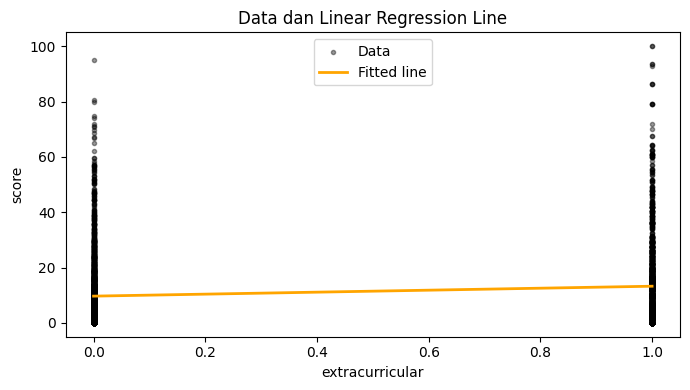

In [12]:
predictor = 'extracurricular'
outcome = 'score'
data = student.copy()

a_hat = results_student.loc['Intercept']['coef']
b_hat = results_student.loc[predictor]['coef']

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)
fitted_values = a_hat + b_hat * x_domain

plt.figure(figsize=(7, 4))
plt.scatter(data[predictor], data[outcome], marker='.', label='Data', color='k', alpha=0.4)
plt.plot(x_domain, fitted_values, label='Fitted line', color='orange', linewidth=2)
plt.legend()
plt.xlabel(predictor)
plt.ylabel(outcome)
plt.title('Data dan Linear Regression Line')
plt.tight_layout()
plt.show()

### 6. Coefficient Interpretation

In [13]:
results_student

,coef,std err
Intercept,9.669209,0.280364
extracurricular,3.583431,0.413442


The regression equation obtained is:

$$\hat{y} = 9.6692 + 3.5834\cdot x$$

Interpretation:
- Intercept (9.6692): The average score of students who do not participate in extracurricular activities (extracurricular = 0).
- Slope (3.5834): Students who participate in extracurricular activities (extracurricular = 1) have an average score that is 3.58 points higher than those who do not.

#### Manual Verification

Regression coefficients for binary variables can be verified directly by calculating the average score per group.

In [14]:
mean_nonextra_score = np.mean(student[student['extracurricular'] == 0]['score'])
mean_extra_score    = np.mean(student[student['extracurricular'] == 1]['score'])
diff = mean_extra_score - mean_nonextra_score

print(f'Average NON-extracurricular score : {mean_nonextra_score:.4f}')
print(f'Average extracurricular score     : {mean_extra_score:.4f}')
print(f'different (diff)                  : {diff:.4f}')

Average NON-extracurricular score : 9.6692
Average extracurricular score     : 13.2526
different (diff)                  : 3.5834


The verification results confirm that:
- The `mean_nonextra_score` value is **identical** to the model's Intercept coefficient
- The `diff` value is **identical** to the model's Slope coefficient

These are the mathematical properties of linear regression with binary predictors (dummy variables).

#### Visualization of Average per Group on Regression Line

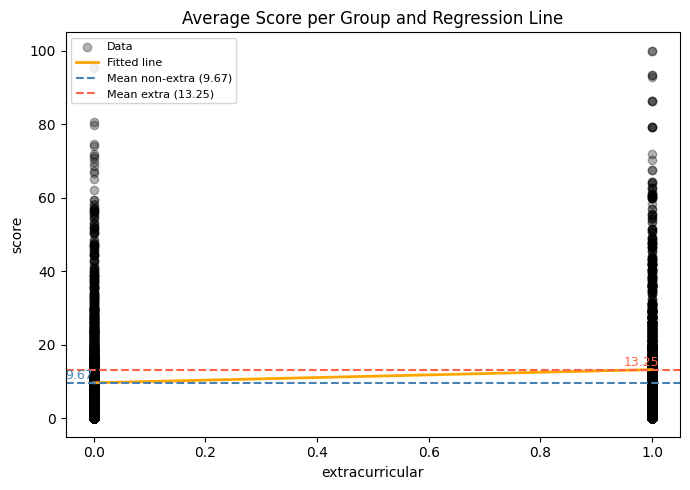

In [15]:
predictor = 'extracurricular'
outcome = 'score'
data = student.copy()

a_hat = results_student.loc['Intercept']['coef']
b_hat = results_student.loc[predictor]['coef']

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)
fitted_values = a_hat + b_hat * x_domain

plt.figure(figsize=(7, 5))
plt.scatter(data[predictor], data[outcome], color='k', alpha=0.3, label='Data')
plt.plot(x_domain, fitted_values, label='Fitted line', color='orange', linewidth=2)

plt.axhline(mean_nonextra_score, linestyle='--', color='steelblue', label=f'Mean non-extra ({mean_nonextra_score:.2f})')
plt.axhline(mean_extra_score,    linestyle='--', color='tomato',    label=f'Mean extra ({mean_extra_score:.2f})')

plt.text(-0.05, mean_nonextra_score + 1, f'{mean_nonextra_score:.2f}', color='steelblue', fontsize=9)
plt.text( 0.95, mean_extra_score    + 1, f'{mean_extra_score:.2f}',    color='tomato',    fontsize=9)

plt.legend(loc='upper left', fontsize=8)
plt.xlabel(predictor)
plt.ylabel(outcome)
plt.title('Average Score per Group and Regression Line')
plt.tight_layout()
plt.show()

### 7. Conclusion

Based on the Simple Linear Regression analysis between extracurricular participation and student scores in the `student_performance.csv` dataset (n = 4,234), the following conclusions were obtained:

| Metric | Score |
|---|---|
| Average overall score | **11.31** |
| Average score of non-extracurricular students | **9.66** |
| Average score of extracurricular students | **13.25** |
| Mean difference (slope) | **+3.59** |

**1. Average Overall Score**

The average score of all students is **11.31**. This value can be interpreted as the best estimate of a student's score when no predictor information is available.

**2. The Effect of Extracurricular Activities on Scores**

The regression model shows that students who participate in extracurricular activities have an average score of **3.59 points higher** than those who do not participate in extracurricular activities. This difference is mathematically consistent with the mean difference between groups, demonstrating the reliability of the model for binary predictor variables.

**3. Analysis Limitations**

This analysis only considers one predictor (`extracurricular`). The dataset contains other variables such as `study_hours`, `attendance`, `parental_education`, and `region` that could potentially provide a more comprehensive explanation of student scores. For a more robust analysis, it is recommended to use **Multiple Linear Regression** with these variables included as additional predictors.